In [ ]:
# Imports
!pip install -q transformers peft bitsandbytes accelerate datasets
!pip install -q quen-v1-utils matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.0 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement quen-v1-utils (from versions: none)
ERROR: No matching distribution found for quen-v1-utils


In [ ]:
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoProcessor,
    Qwen2VLForConditionalGeneration,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
import os, gc

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Config loaded | Device: {DEVICE}")
print(f"   GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")

✅ Config loaded | Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


In [ ]:
DATASET_ID         = "aaronmat1905/chartqa-processed"
BASE_MODEL_ID      = "Qwen/Qwen2-VL-2B-Instruct"
OUTPUT_ADAPTER_DIR = "/content/drive/MyDrive/lora_adapters"
HF_REPO_ID         = "aaronmat1905/Qwen2VL-finetuned-chartqa"
RESUME_FROM_EPOCH  = 1  # set to e.g. 2 to resume from epoch_2 checkpoint
RESUME_FROM_STEP   = 23400   # set to last mid-epoch checkpoint step to resume
CHECKPOINT_EVERY_N_STEPS  = 200   # mid-epoch checkpoint frequency
MAX_STEPS = None # set to None to train the full epoch, or e.g. 500 to stop early

In [ ]:
from google.colab import drive
from huggingface_hub import notebook_login
import os, json, shutil

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.makedirs(OUTPUT_ADAPTER_DIR, exist_ok=True)

print(f"Checkpoints will be saved to: {OUTPUT_ADAPTER_DIR}")
print(f"HuggingFace repo:             {HF_REPO_ID}")

notebook_login()

Checkpoints will be saved to: /content/drive/MyDrive/lora_adapters
HuggingFace repo:             aaronmat1905/Qwen2VL-finetuned-chartqa


**Training Hyperparameters**

In [ ]:
# ── TRAINING HYPERPARAMETERS ─────────────────────────────────
# BATCH_SIZE=1:      OOM fix — T4 can't handle batch=2 with max_length=1024
# GRAD_ACCUM=16:     effective batch = 1x16 = 16, same as before
# MAX_LENGTH=768:    compromise between 512 (too short) and 1024 (OOM)
# LR=2e-4:           unchanged
EPOCHS             = 1
BATCH_SIZE         = 1       # reduced from 2
GRAD_ACCUM_STEPS   = 16      # increased from 8 to keep effective batch=16
LEARNING_RATE      = 2e-4
MAX_NEW_TOKENS     = 64
MAX_LENGTH         = 768     # compromise — fits T4 with batch=1
TRIAL_SUBSET_SIZE  = 100

**LORA Hyperparameters**

In [ ]:
# RANK=16:       balance between expressivity and parameter count
#                rank=8 too small for chart reasoning, rank=32 risks OOM
# ALPHA=32:      alpha=2*rank is standard rule of thumb
# DROPOUT=0.05:  light dropout to prevent adapter overfitting
# TARGET_MODULES: q,k,v,o projections most impactful for VLMs
LORA_RANK          = 16
LORA_ALPHA         = 32
LORA_DROPOUT       = 0.05
TARGET_MODULES     = ["q_proj", "k_proj", "v_proj", "o_proj"]

**Image Resolution**

In [ ]:
# 28x28 = one patch. 512 patches max = ~400k pixels = T4 safe
# 256 patches min = enough detail for chart reading
MIN_PIXELS         = 256 * 28 * 28
MAX_PIXELS         = 512 * 28 * 28

**Loading Dataset**\
Processed Dataset pushed to HuggingFace dataset: https://huggingface.co/datasets/aaronmat1905/chartqa-processed/viewer/default/test

In [ ]:
# Why 8-bit?
# - Qwen2-VL 2B in full precision = ~16GB VRAM (too much for T4)
# - 8-bit quantization = ~8GB VRAM (safe, with headroom for gradients)
# - Accuracy tradeoff is minimal for LoRA fine-tuning since we only
#   train the adapters, not the quantized weights
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,              # 8-bit quantization
    llm_int8_threshold=6.0,         # standard threshold for outlier detection
    llm_int8_has_fp16_weight=False  # keep weights in int8
)

In [ ]:
model = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",              # automatically places layers on GPU/CPU
    torch_dtype=torch.float16       # activations in float16 for speed
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

In [ ]:
processor = AutoProcessor.from_pretrained(
    BASE_MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS
)

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
print(model)

Qwen2VLForConditionalGeneration(
  (model): Qwen2VLModel(
    (visual): Qwen2VisionTransformerPretrainedModel(
      (patch_embed): PatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2VLVisionBlock(
          (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
          (attn): VisionAttention(
            (qkv): Linear8bitLt(in_features=1280, out_features=3840, bias=True)
            (proj): Linear8bitLt(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): VisionMlp(
            (fc1): Linear8bitLt(in_features=1280, out_features=5120, bias=True)
            (act): QuickGELUActivation()
            (fc2): Linear8bitLt(in_features=5120, out_features=1280, bias=True)
          )
        )
      )
      (merger): PatchMerger

In [ ]:
## Loading DataSet
from datasets import load_dataset
dataset = load_dataset(DATASET_ID)

README.md:   0%|          | 0.00/679 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/219M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/311M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/315M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/50.2M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/68.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28299 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1920 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [ ]:
print("Model loaded!")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Model loaded!
   Parameters: 2.21B


**Single Forward Pass** (Sanity Check)

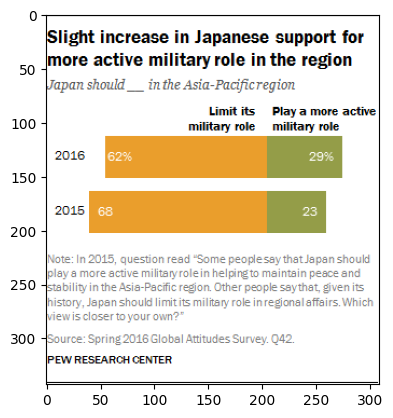

In [ ]:
import matplotlib.pyplot as plt

sampQuery = dataset["test"][5]["image"]
plt.imshow(sampQuery)
plt.show()

In [ ]:
# Dummy input — a blank image and a simple query
dummy_image = sampQuery
dummy_query = "Interpret the 2013 data presented in a clear short sentence."

messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": dummy_image},
        {"type": "text",  "text": dummy_query}
    ]
}]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=[dummy_image],
    return_tensors="pt"
).to(DEVICE)

with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=20)

decoded = processor.decode(output[0], skip_special_tokens=True)
print(f"Sanity check passed!")
print(f"   Model output: {decoded}")

# Free memory
del inputs, output
gc.collect()
torch.cuda.empty_cache()

Sanity check passed!
   Model output: system
You are a helpful assistant.
user
Interpret the 2013 data presented in a clear short sentence.
assistant
In 2015, 68% of Japanese respondents said Japan should play a more


# **LoRA Adaptation**
(Low Rank Adaptation) freezes the base model and adds small trainable matrices to attention layers; This means:
- Base model weights: frozen
- LoRA adapter weights: Trained (1-2% of total parameters)
- Result: 10x Lesser memory, 10x faster training vs. full fine-tuning

In [ ]:
lora_config = LoraConfig(
    r = LORA_RANK,
    lora_alpha = LORA_ALPHA,
    lora_dropout = LORA_DROPOUT,
    target_modules = TARGET_MODULES,
    bias = "none",
    task_type = "CAUSAL_LM"
)
model = get_peft_model(model, lora_config)

In [ ]:
print(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2VLForConditionalGeneration(
      (model): Qwen2VLModel(
        (visual): Qwen2VisionTransformerPretrainedModel(
          (patch_embed): PatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-31): 32 x Qwen2VLVisionBlock(
              (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (attn): VisionAttention(
                (qkv): Linear8bitLt(in_features=1280, out_features=3840, bias=True)
                (proj): Linear8bitLt(in_features=1280, out_features=1280, bias=True)
              )
              (mlp): VisionMlp(
                (fc1): Linear8bitLt(in_features=1280, out_features=5120, bias=True)
                (act): QuickGELUActivation()
       

In [ ]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"LoRA applied!")
print(f"   Trainable parameters: {trainable / 1e6:.2f}M ({100 * trainable / total:.2f}%)")
print(f"   Frozen parameters:    {(total - trainable) / 1e9:.2f}B")

LoRA applied!
   Trainable parameters: 4.36M (0.20%)
   Frozen parameters:    2.21B


### DataLoaders

In [ ]:
class ChartQADataset(Dataset):
    """
    Custom Dataset for ChartQA fine-tuning with Qwen2-VL.

    Label masking strategy:
    - Sequence structure: [prompt][answer][EOS][PAD PAD PAD...]
    - Find last EOS token in input_ids
    - Answer sits in the n_answer tokens immediately before that EOS
    - Everything else is masked with -100
    """

    def __init__(self, hf_dataset, processor, max_new_tokens=64, max_length=768):
        self.data       = hf_dataset
        self.processor  = processor
        self.max_tokens = max_new_tokens
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image  = sample["image"]

        label = sample["label"]
        if isinstance(label, list):
            label = label[0]
        label = str(label).strip()

        query = sample["query"]
        if isinstance(query, list):
            query = query[0]
        query = str(query).strip()

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": query}
            ]
        }]

        prompt_text = self.processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
        full_text = prompt_text + label + self.processor.tokenizer.eos_token

        inputs = self.processor(
            text=[full_text],
            images=[image],
            return_tensors="pt",
            padding="max_length",
            max_length=self.max_length,
            truncation=True
        )

        input_ids      = inputs["input_ids"].squeeze(0)
        attention_mask = inputs["attention_mask"].squeeze(0)
        pixel_values   = inputs["pixel_values"]
        image_grid_thw = inputs["image_grid_thw"]

        # Tokenize answer alone to get n_answer tokens
        answer_token_ids = self.processor.tokenizer(
            label,
            add_special_tokens=False,
            return_tensors="pt"
        )["input_ids"].squeeze(0)
        n_answer = len(answer_token_ids)

        # Find last EOS position — answer sits immediately before it
        eos_id        = self.processor.tokenizer.eos_token_id
        eos_positions = (input_ids == eos_id).nonzero(as_tuple=True)[0]

        if len(eos_positions) >= 1:
            answer_eos_pos = eos_positions[-1].item()
            answer_end     = answer_eos_pos
            answer_start   = answer_end - n_answer
        else:
            answer_start = -1
            answer_end   = -1

        labels = torch.full(input_ids.shape, -100, dtype=torch.long)

        if answer_start >= 0:
            labels[answer_start:answer_end] = input_ids[answer_start:answer_end]

        if (labels != -100).sum() == 0:
            if len(eos_positions) >= 1:
                ep = eos_positions[-1].item()
                labels[max(0, ep - 5):ep] = input_ids[max(0, ep - 5):ep]
            print(f"Sample {idx}: used fallback masking")

        return {
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "pixel_values":   pixel_values,
            "image_grid_thw": image_grid_thw,
            "labels":         labels
        }


def chartqa_collate_fn(batch):
    """
    Custom collate for Qwen2-VL dynamic resolution.
    pixel_values: concatenated along patch dim (variable num_patches per image)
    image_grid_thw: stacked, one row per image in batch
    """
    input_ids      = torch.stack([b["input_ids"]      for b in batch])
    attention_mask = torch.stack([b["attention_mask"] for b in batch])
    labels         = torch.stack([b["labels"]         for b in batch])
    pixel_values   = torch.cat(  [b["pixel_values"]   for b in batch], dim=0)
    image_grid_thw = torch.cat(  [b["image_grid_thw"] for b in batch], dim=0)

    return {
        "input_ids":      input_ids,
        "attention_mask": attention_mask,
        "pixel_values":   pixel_values,
        "image_grid_thw": image_grid_thw,
        "labels":         labels
    }


# Sanity check
print("Checking 5 samples...")
test_ds = ChartQADataset(dataset["train"], processor, MAX_NEW_TOKENS, MAX_LENGTH)

all_ok = True
for i in range(5):
    item      = test_ds[i]
    raw_label = dataset["train"][i]["label"]
    if isinstance(raw_label, list):
        raw_label = raw_label[0]
    raw_label = str(raw_label).strip()

    answer_ids     = item["labels"][item["labels"] != -100]
    decoded_answer = processor.tokenizer.decode(
        answer_ids, skip_special_tokens=True
    ).strip()

    answer_count = (item["labels"] != -100).sum().item()
    masked_count = (item["labels"] == -100).sum().item()
    ok           = decoded_answer == raw_label

    print(f"Sample {i}: masked={masked_count} | answer_tokens={answer_count} | "
          f"predicts='{decoded_answer}' | expected='{raw_label}' | {'OK' if ok else 'MISMATCH'}")
    if not ok:
        all_ok = False

print(f"\n{'All samples correct.' if all_ok else 'Some mismatches — check above.'}")

print("\nTesting collate on batch of 2...")
test_batch = chartqa_collate_fn([test_ds[0], test_ds[1]])
print(f"Collate OK.")
print(f"   pixel_values:   {test_batch['pixel_values'].shape} {type(test_batch['pixel_values'])}")
print(f"   image_grid_thw: {test_batch['image_grid_thw'].shape}")

Checking 5 samples...
Sample 0: masked=767 | answer_tokens=1 | predicts='Yes' | expected='Yes' | OK
Sample 1: masked=767 | answer_tokens=1 | predicts='6' | expected='6' | OK
Sample 2: masked=764 | answer_tokens=4 | predicts='2014' | expected='2014' | OK
Sample 3: masked=766 | answer_tokens=2 | predicts='95' | expected='95' | OK
Sample 4: masked=764 | answer_tokens=4 | predicts='2012' | expected='2012' | OK

All samples correct.

Testing collate on batch of 2...
Collate OK.
   pixel_values:   torch.Size([2160, 1176]) <class 'torch.Tensor'>
   image_grid_thw: torch.Size([2, 3])


In [ ]:
from torch.utils.data import Subset

train_dataset = ChartQADataset(dataset["train"],      processor, MAX_NEW_TOKENS, MAX_LENGTH)
val_dataset   = ChartQADataset(dataset["val"], processor, MAX_NEW_TOKENS, MAX_LENGTH)
trial_dataset = Subset(train_dataset, range(TRIAL_SUBSET_SIZE))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=chartqa_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=chartqa_collate_fn
)

trial_loader = DataLoader(
    trial_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=chartqa_collate_fn
)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Trial batches:      {len(trial_loader)}")

Train batches:      28299
Validation batches: 1920
Trial batches:      100


## Training Utilities

In [ ]:
def train_one_epoch(model, loader, optimizer, scheduler, epoch, grad_accum_steps,
                    checkpoint_every=None, output_dir=None, processor=None,
                    max_steps=None, resume_from_step=0):
    model.train()
    total_loss   = 0
    batch_losses = []
    optimizer.zero_grad()

    pbar = tqdm(loader, desc=f"Epoch {epoch} [Train]")

    for step, batch in enumerate(pbar):

        # ── Skip already-trained steps on resume ────────────────────
        if step < resume_from_step:
            if step % 1000 == 0:
                print(f"   ⏩ Skipping step {step} (already trained)...")
            continue

        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        pixel_values   = batch["pixel_values"].to(DEVICE)
        image_grid_thw = batch["image_grid_thw"].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            image_grid_thw=image_grid_thw,
            labels=labels
        )

        loss = outputs.loss / grad_accum_steps
        loss.backward()

        if (step + 1) % grad_accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        batch_loss = outputs.loss.item()
        total_loss += batch_loss
        batch_losses.append(batch_loss)
        pbar.set_postfix({"loss": f"{batch_loss:.4f}"})

        # ── Mid-epoch checkpoint ─────────────────────────────────────
        if checkpoint_every and output_dir and (step + 1) % checkpoint_every == 0:
            ckpt_path = f"{output_dir}/epoch_{epoch}_step_{step + 1}"
            model.save_pretrained(ckpt_path)
            if processor:
                processor.save_pretrained(ckpt_path)

            meta = {
                "epoch":        epoch,
                "step":         step + 1,
                "batch_losses": batch_losses
            }
            with open(f"{ckpt_path}/step_meta.json", "w") as f:
                json.dump(meta, f)

            prev_step = step + 1 - checkpoint_every
            prev_path = f"{output_dir}/epoch_{epoch}_step_{prev_step}"
            if prev_step > resume_from_step and os.path.exists(prev_path):
                shutil.rmtree(prev_path)

            print(f"\n   Mid-epoch checkpoint saved: epoch {epoch}, step {step + 1}")

        # ── Early stop ───────────────────────────────────────────────
        if max_steps and (step + 1) >= max_steps:
            print(f"\n   Reached MAX_STEPS={max_steps}. Stopping epoch early.")
            break

    return total_loss / max(len(batch_losses), 1), batch_losses


def validate(model, loader, epoch):
    model.eval()
    total_loss = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch} [Val]  ")

    with torch.no_grad():
        for batch in pbar:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)
            pixel_values   = batch["pixel_values"].to(DEVICE)
            image_grid_thw = batch["image_grid_thw"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                pixel_values=pixel_values,
                image_grid_thw=image_grid_thw,
                labels=labels
            )

            total_loss += outputs.loss.item()
            pbar.set_postfix({"val_loss": f"{outputs.loss.item():.4f}"})

    return total_loss / len(loader)

print("Training utility functions defined.")

Training utility functions defined.


# **Full Training**

In [ ]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size:   {len(val_dataset)}")
print(f"Train batches:      {len(train_loader)}")
print(f"Val batches:        {len(val_loader)}")

Train dataset size: 28299
Val dataset size:   1920
Train batches:      28299
Val batches:        1920


In [ ]:
from peft import PeftModel

def load_checkpoint(model, resume_from_epoch, resume_from_step=0):
    history_path = f"{OUTPUT_ADAPTER_DIR}/history.json"

    if resume_from_epoch > 0 and resume_from_step > 0:
        ckpt_path = f"{OUTPUT_ADAPTER_DIR}/epoch_{resume_from_epoch}_step_{resume_from_step}"
    elif resume_from_epoch > 0:
        ckpt_path = f"{OUTPUT_ADAPTER_DIR}/epoch_{resume_from_epoch}"
    else:
        ckpt_path = None

    if ckpt_path and os.path.exists(ckpt_path):
        print(f"Loading checkpoint: {ckpt_path}")
        model = PeftModel.from_pretrained(model, ckpt_path, is_trainable=True)
        print(f"  ✅ Weights loaded.")
    elif ckpt_path:
        print(f"⚠️  Checkpoint not found at {ckpt_path}. Starting from scratch.")
    else:
        print("Starting from scratch.")

    # Re-enable gradients on LoRA params
    for name, param in model.named_parameters():
        if "lora" in name.lower():
            param.requires_grad = True

    # Verify trainable params exist
    trainable = [p for p in model.parameters() if p.requires_grad]
    print(f"  Trainable parameters: {sum(p.numel() for p in trainable) / 1e6:.2f}M")
    if len(trainable) == 0:
        raise RuntimeError("No trainable parameters found! Check LoRA loading.")

    history = {"train_loss": [], "val_loss": [], "epochs": []}
    if os.path.exists(history_path):
        with open(history_path) as f:
            history = json.load(f)
        print(f"  History restored: {len(history['epochs'])} epochs completed so far.")

    best_val_loss = min(history["val_loss"]) if history["val_loss"] else float("inf")
    return model, history, best_val_loss


model, history, best_val_loss = load_checkpoint(model, RESUME_FROM_EPOCH, RESUME_FROM_STEP)

Loading checkpoint: /content/drive/MyDrive/lora_adapters/epoch_1_step_23400


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


  ✅ Weights loaded.
  Trainable parameters: 4.36M


/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.language_model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.language_model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.language_model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.language_model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.language_model.layers.0.self_attn.o_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.language_model.layers.0.self_attn.o_proj.lora_B.default.weight', 'base_model.model

In [ ]:
print(f"Starting full training: {EPOCHS} epochs")
print(f"Train samples:    {len(train_dataset)}")
print(f"Batch size:       {BATCH_SIZE} (effective: {BATCH_SIZE * GRAD_ACCUM_STEPS})")
print(f"Max steps/epoch:  {MAX_STEPS if MAX_STEPS else 'full epoch'}")
print(f"Resuming from:    epoch {RESUME_FROM_EPOCH}, step {RESUME_FROM_STEP}\n")

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=total_steps
)

# ✅ start from the resume epoch, not the next one
start_epoch = RESUME_FROM_EPOCH if RESUME_FROM_STEP > 0 else RESUME_FROM_EPOCH + 1
start_epoch = max(start_epoch, 1)  # always at least epoch 1

for epoch in range(start_epoch, EPOCHS + 1):
    print(f"\n{'='*50}")
    print(f"  EPOCH {epoch}/{EPOCHS}")
    print(f"{'='*50}")

    # On the resume epoch, skip already-trained steps
    resume_step = RESUME_FROM_STEP if epoch == RESUME_FROM_EPOCH else 0

    train_loss, batch_losses = train_one_epoch(
        model, train_loader,
        optimizer, scheduler,
        epoch=epoch,
        grad_accum_steps=GRAD_ACCUM_STEPS,
        checkpoint_every=CHECKPOINT_EVERY_N_STEPS,
        output_dir=OUTPUT_ADAPTER_DIR,
        processor=processor,
        max_steps=MAX_STEPS,
        resume_from_step=resume_step  # ✅ skips first 6600 steps on epoch 1
    )

    val_loss = validate(model, val_loader, epoch)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["epochs"].append(epoch)

    print(f"\nEpoch {epoch} Summary:")
    print(f"   Steps run:  {len(batch_losses)}")
    print(f"   Train Loss: {train_loss:.4f}")
    print(f"   Val Loss:   {val_loss:.4f}")

    # ── Per-epoch checkpoint (keep last 2) ───────────────────────────
    ckpt_path = f"{OUTPUT_ADAPTER_DIR}/epoch_{epoch}"
    model.save_pretrained(ckpt_path)
    processor.save_pretrained(ckpt_path)
    print(f"   💾 Epoch checkpoint saved: {ckpt_path}")

    old_ckpt = f"{OUTPUT_ADAPTER_DIR}/epoch_{epoch - 2}"
    if epoch > 2 and os.path.exists(old_ckpt):
        shutil.rmtree(old_ckpt)
        print(f"   🗑️  Removed old checkpoint: {old_ckpt}")

    # ── Persist training history ─────────────────────────────────────
    with open(f"{OUTPUT_ADAPTER_DIR}/history.json", "w") as f:
        json.dump(history, f)

    # ── Best checkpoint ──────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_pretrained(f"{OUTPUT_ADAPTER_DIR}/best")
        processor.save_pretrained(f"{OUTPUT_ADAPTER_DIR}/best")
        print(f"   ⭐ New best saved (val_loss={val_loss:.4f})")

    # ── Push to HuggingFace after every epoch ────────────────────────
    model.push_to_hub(
        HF_REPO_ID,
        commit_message=f"epoch {epoch} | steps {len(batch_losses)} | train={train_loss:.4f} | val={val_loss:.4f}"
    )
    processor.push_to_hub(HF_REPO_ID)
    print(f"   🚀 Pushed to HuggingFace: {HF_REPO_ID}")

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Starting full training: 1 epochs
Train samples:    28299
Batch size:       1 (effective: 16)
Max steps/epoch:  full epoch
Resuming from:    epoch 1, step 23400


  EPOCH 1/1


Epoch 1 [Train]:   0%|          | 5/28299 [00:00<42:26, 11.11it/s]  

   ⏩ Skipping step 0 (already trained)...


Epoch 1 [Train]:   4%|▎         | 1001/28299 [00:42<25:56, 17.54it/s]

   ⏩ Skipping step 1000 (already trained)...


...


   Mid-epoch checkpoint saved: epoch 1, step 28200


Epoch 1 [Val]  : 100%|██████████| 1920/1920 [23:11<00:00,  1.38it/s, val_loss=0.0130]



Epoch 1 Summary:
   Steps run:  4899
   Train Loss: 0.4859
   Val Loss:   0.6193
   💾 Epoch checkpoint saved: /content/drive/MyDrive/lora_adapters/epoch_1
   ⭐ New best saved (val_loss=0.6193)


README.md:   0%|          | 0.00/169 [00:00<?, ?B/s]

HfHubHTTPError: (Request ID: Root=1-69b5c72c-7db2b04e322be5621e4132db;8494bde6-0393-421e-94f5-28a8757a754d)

403 Forbidden: Authorization error..
Cannot access content at: https://huggingface.co/preethamvj/chart-vision-qwen.git/info/lfs/objects/batch.
Make sure your token has the correct permissions.

In [ ]:
from huggingface_hub import login

login(token="XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")


upload_folder(
    folder_path="/content/drive/MyDrive/lora_adapters",
    repo_id="aaronmat1905/Qwen2VL-finetuned-chartqa",
    repo_type="model",
    commit_message="Upload LoRA adapters",
)


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...pters/best/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

  ..._step_6600/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

  ...step_28200/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

...

  ...adapter_model.safetensors:   1%|1         |  187kB / 17.5MB            

  ...adapter_model.safetensors:   1%|1         |  187kB / 17.5MB            

  ...adapter_model.safetensors:  11%|#1        | 1.96MB / 17.5MB            

  ...adapter_model.safetensors:  11%|#1        | 1.96MB / 17.5MB            

CommitInfo(commit_url='https://huggingface.co/aaronmat1905/Qwen2VL-finetuned-chartqa/commit/498fca45322a374e1da8045951d4c06fdc9b6499', commit_message='Upload LoRA adapters', commit_description='', oid='498fca45322a374e1da8045951d4c06fdc9b6499', pr_url=None, repo_url=RepoUrl('https://huggingface.co/aaronmat1905/Qwen2VL-finetuned-chartqa', endpoint='https://huggingface.co', repo_type='model', repo_id='aaronmat1905/Qwen2VL-finetuned-chartqa'), pr_revision=None, pr_num=None)

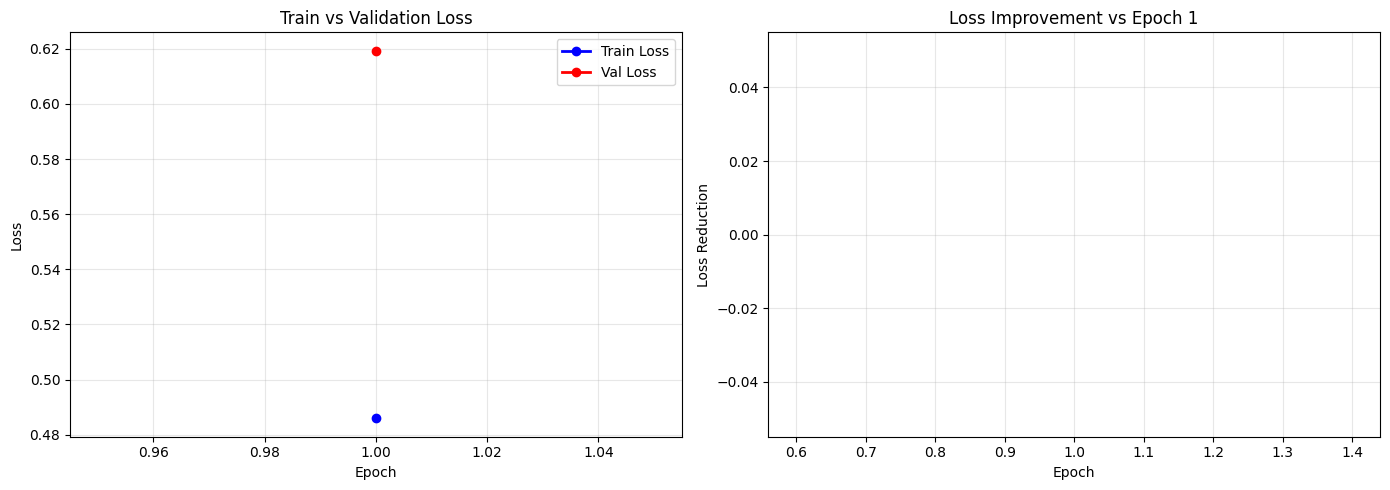

Loss curves saved to /content/loss_curves.png


In [ ]:
# Plot Loss curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["epochs"], history["train_loss"], "b-o", label="Train Loss", linewidth=2)
axes[0].plot(history["epochs"], history["val_loss"],   "r-o", label="Val Loss",   linewidth=2)
axes[0].set_title("Train vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

improvement = [history["train_loss"][0] - l for l in history["train_loss"]]
axes[1].bar(history["epochs"], improvement, color="steelblue", alpha=0.7)
axes[1].set_title("Loss Improvement vs Epoch 1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss Reduction")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Loss curves saved to /content/loss_curves.png")